In [2]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import numpy as np
import os
from sklearn.linear_model import LinearRegression
import copy
import pandas as pd
from funciones import J_univariante, J_bivariante, interpolador, interpolador_constante, interpolador_estocastico, derivada_index, remove_consecutive_duplicates, brownian_bridge, generar_uniforme_centrada
from scipy.interpolate import PchipInterpolator


In [3]:
#dataframe datos de compositores 
def extraer_dataset_musica():

    datos_composers = {}
    carpeta = r'data\Sequences\labels'
    archivos_en_carpeta = os.listdir(carpeta)
    index0 = 0
    indice = 0

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa, header = None)
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        datos_composers[composer] = {} #genero bibio para composer
        datos_composers[composer]['Birth_year'] = archivo.split('-')[0] #año de nacimiento
        index1 = serie.iloc[0, 0].split('\t')[0] #el # del primer serie del composer
        index2 = int(serie.iloc[len(serie)-3, 0].split('\t')[0]) - index0 # # Piezas
        index0 = index2 + index0 # numero total de piezas anteriores
        datos_composers[composer]['# Piezas'] = index2 # Piezas
        datos_composers[composer]['Indice'] = indice
        indice += 1

    composers = {}
    M = 0
    carpeta = r'data\Sequences\Series'
    archivos_en_carpeta = os.listdir(carpeta)

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa)
        # escoge una serie
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        composers[composer] = {}

        for pieza in range( datos_composers[composer]['# Piezas'] ):
            N = serie.iloc[0, 0].split('\t')[1] # # de elementos por pieza
            M = int(N) + M
            index_n1 = 0 
            index_n2 = int(N)+2 
            serie_n = serie[index_n1 + 2:index_n2].reset_index(drop=True) # resetear index
            serie = serie[index_n2 +1:] # recortar serie Original
            serie_n.index += 1 # que index empiece desde 1
            num_serie_T = serie.columns[0]  # numero de serie de todo el dataset
            num_serie = pieza + 1
            composers[composer]['Serie_'+str(num_serie)] = serie_n.squeeze().to_numpy().astype(float) # agregamos pieza al dicc composer con key como # serie

    ###
    ###

    composers_depurado = copy.deepcopy(composers)
    datos_composers_depurado = copy.deepcopy(datos_composers)

    for i,composer in enumerate(composers.keys()):
        d = 0
        for pieza in composers[composer].keys():
            if len(composers[composer][pieza])//2 < 400:
                del composers_depurado[composer][pieza]
                d = d + 1
        datos_composers_depurado[composer]['# Piezas'] = datos_composers[composer]['# Piezas'] - d


    # 40 promedio de numero de piezas por compositor
    composers_depurado_v2 = copy.deepcopy(composers_depurado)
    composers_depurado_v2_keychange = copy.deepcopy(composers_depurado_v2)
    datos_composers_depurado_v2 = copy.deepcopy(datos_composers_depurado)

    for composer in composers.keys():
        if datos_composers_depurado[composer]['# Piezas'] < 30:
            del composers_depurado_v2[composer]
            del datos_composers_depurado_v2[composer]
        
    for i,composer in enumerate(composers_depurado_v2.keys()):
        datos_composers_depurado_v2[composer]['Indice'] = i 

    for composer in composers_depurado_v2.keys():
        for i,serie in enumerate(composers_depurado_v2[composer].keys()):
            composers_depurado_v2_keychange[composer]['Serie_' + str(i+1)] = composers_depurado_v2_keychange[composer].pop(serie)

    print(" # de compositores restantes: ", len(composers_depurado_v2))

    return composers_depurado_v2, datos_composers_depurado_v2

composers, datos_composers = extraer_dataset_musica()

 # de compositores restantes:  19


# Calculos

In [5]:
# import numpy as np
# xi_index = np.array([])
# for composer in composers.keys():
#     xi_index = np.concatenate((xi_index,np.load('xi_index1/'+str(datos_composers[composer]['Birth_year'])+'_'+str(composer)+'_xi.npy')[:,1]))
# np.save('xi_index_global.npy',xi_index)

(2, 189991)
mean 0.0720455789036759


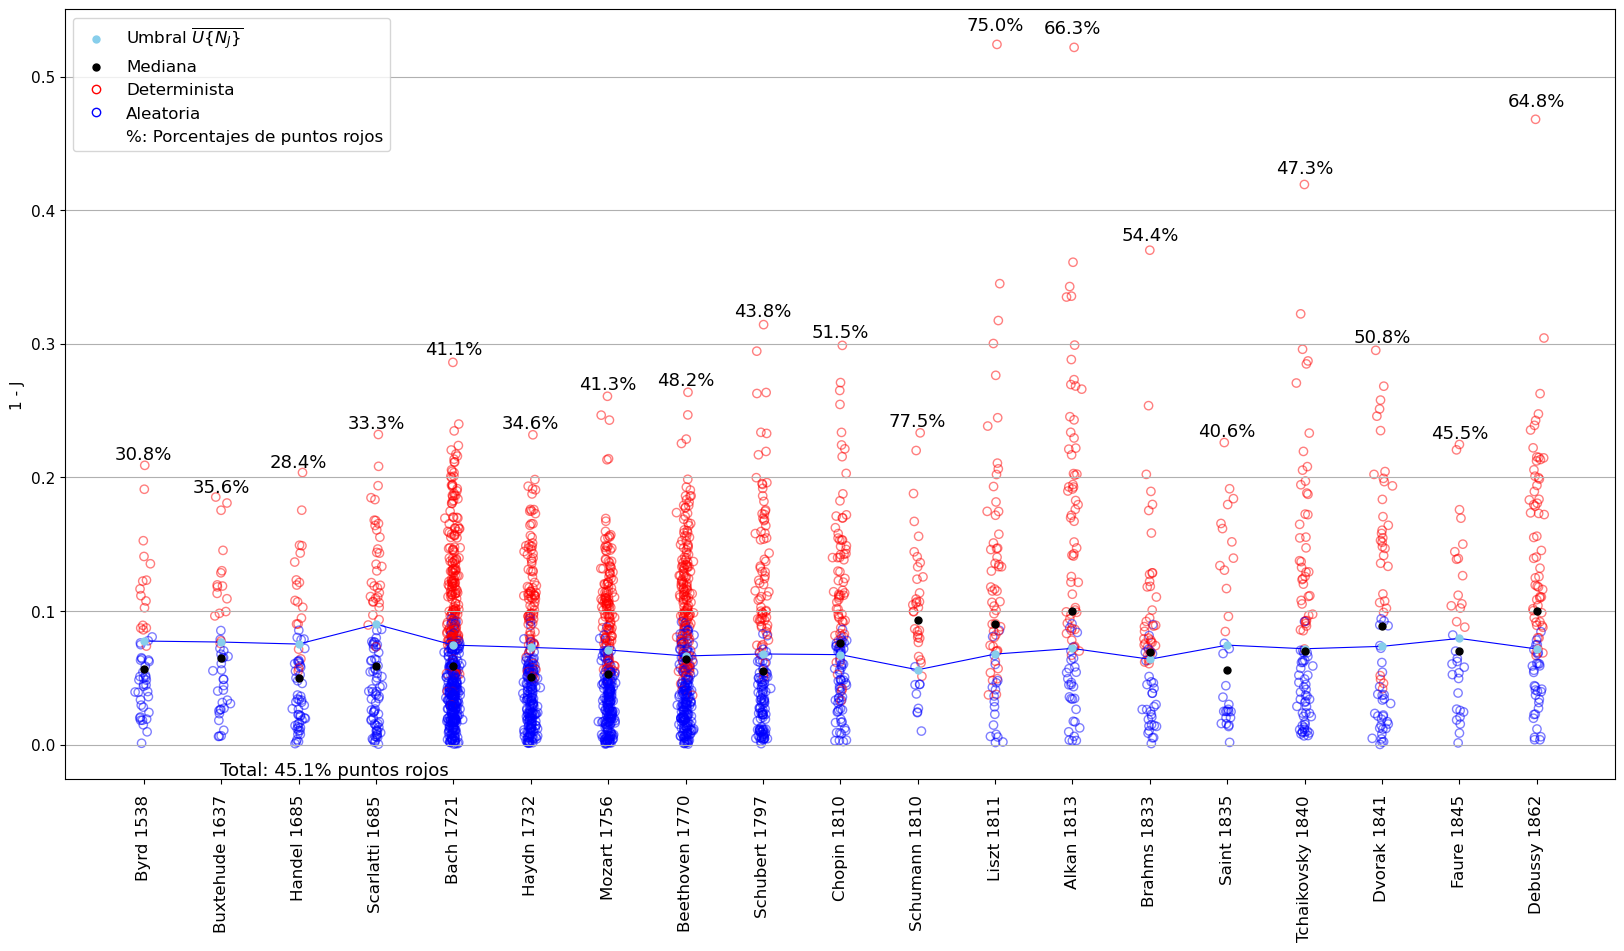

In [6]:
"""Scatter J"""

import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from matplotlib.lines import Line2D

num_compositores = 19
Ns = np.load('data/Ns_depurado.npy')
J_null_matrix = np.load(r'new_data\J_null_continuo.npy')
J_minus = J_null_matrix[:2,:]
# J_minus = np.load('data\J_minus_continuo.npy')
print(np.shape(J_minus))

pts_interp = 2
carpeta2 = 'data/J_lineal_sincorte_depurado/interp_'+str(pts_interp)
# carpeta2 = 'data/J_hermite_sincorte_depurado/interp_'+str(pts_interp) 
carpeta_new = 'new_data/Js_interp2'

archivos_en_carpeta2 = os.listdir(carpeta2)
archivos_en_carpeta_new = os.listdir(carpeta_new)

data2 = [1 - np.sort(np.load(os.path.join(carpeta2, array)))[:] for array in archivos_en_carpeta2]
Ns_data = [Ns[array] for array in range(np.shape(Ns)[0])]
J_OG = [1-np.load('data\J_composers_Hz_depurado.npy')[array] for array in range(np.shape(Ns)[0])]
J_new = [1-np.sort(np.load(os.path.join(carpeta_new, array)))[:] for array in archivos_en_carpeta_new]

data2 = [array[~np.isnan(array)] for array in J_new]
Ns_data = [array[~np.isnan(array)] for array in Ns_data]
J_OG = [array[~np.isnan(array)] for array in J_OG]

# for j in range(num_compositores):
#     for i in range(len(Ns_data[j])):
#         Ns_data[j][i] = (Ns_data[j][i] - 1)*pts_interp + Ns_data[j][i]
#         if Ns_data[j][i]//2 >= 13920:
#             Ns_data[j][i] = 27840

umbral = [[1-J_minus[1, np.where(J_minus[0] == i//2)[0]][0] for i in Ns_data[j]] for j in range(num_compositores)]
# Aquí, asume que `puntos` es la lista con los num_compositores elementos
# puntos1 = [J_minus[int(np.mean(Ns_data[j])) - 20] for j in range(num_compositores)]
puntos2 = [1-np.mean(np.array([J_minus[1, np.where(J_minus[0] == i//2)[0]] for i in Ns_data[j]])) for j in range(num_compositores)]
mediana = [np.median(array) for array in data2]
print('mean',np.mean(puntos2))
fig, ax = plt.subplots(figsize=(20, 10))
# box2 = ax.boxplot(data2, patch_artist=True)

total_red_points = 0
total_points = 0
porcentajes = []
for i, (d, u) in enumerate(zip(data2, umbral)):
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['blue' if d_val < u_val else 'red' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    y_text = min(max(d) + 0.05, ax.get_ylim()[1] - 0.05)  # Limitar la posición de texto al margen superior
    
    # Añadir texto con el porcentaje
    ax.text(i + 1,np.max(d)*1.02, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ymin = ax.get_ylim()[0]   # límite inferior actual del eje y
xmin = ax.get_xlim()[0]   # si quieres fijarlo también en el mínimo de x, por ejemplo

# Añadir texto en coordenadas de datos
ax.text(xmin + 0.1*(ax.get_xlim()[1]-ax.get_xlim()[0]),  # un poquito a la derecha del xmin
        ymin,                                            # justo en ymin
        f'Total: {total_percentage_red:.1f}% puntos rojos',
        ha='left', va='bottom', fontsize=13, color='black')

# ax.set_xlabel(f'Distribución del índice (1-J) con interpolación lineal de {pts_interp} pts', fontsize=13)
# ax.set_xlabel(f'Distribución del índice (1-J) de las melodias de larga duración', fontsize=13)
ax.set_ylabel('1 - J', fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, num_compositores+1))

# ax.scatter(np.arange(1, 78), puntos1, color='red', s=50, zorder=3, marker = '*', label=r'$U\{\overline{N_J}\}$')
ax.scatter(np.arange(1, num_compositores+1), puntos2, color='#87CEEB', s=25, zorder=3, marker = 'o', label=r'Umbral $\overline{U\{ N_J \}}$')
# ax.axhline(y=0.029071461469613136)
ax.scatter(np.arange(1, num_compositores+1), mediana, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.plot(np.arange(1, num_compositores+1), puntos2, color='blue', linestyle='-', linewidth=0.8)
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Determinista')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Aleatoria')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
# ax.legend(handles=legend_elements)
ax.legend(loc='upper left',fontsize=12)
# ax.xaxis.set_label_position('top')  # Movemos la etiqueta del eje x
# ax.xaxis.tick_top()  # Movemos los ticks del eje x a la parte superior
# ax.spines['top'].set_position(('axes', 1.0))  # Movemos la espina superior al tope de la figura
# ax.spines['bottom'].set_position(('axes', -0.1))  # Ocultamos la espina inferior
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(datos_composers.keys())], rotation=90,fontsize=12)
plt.grid(axis='y')
plt.show()

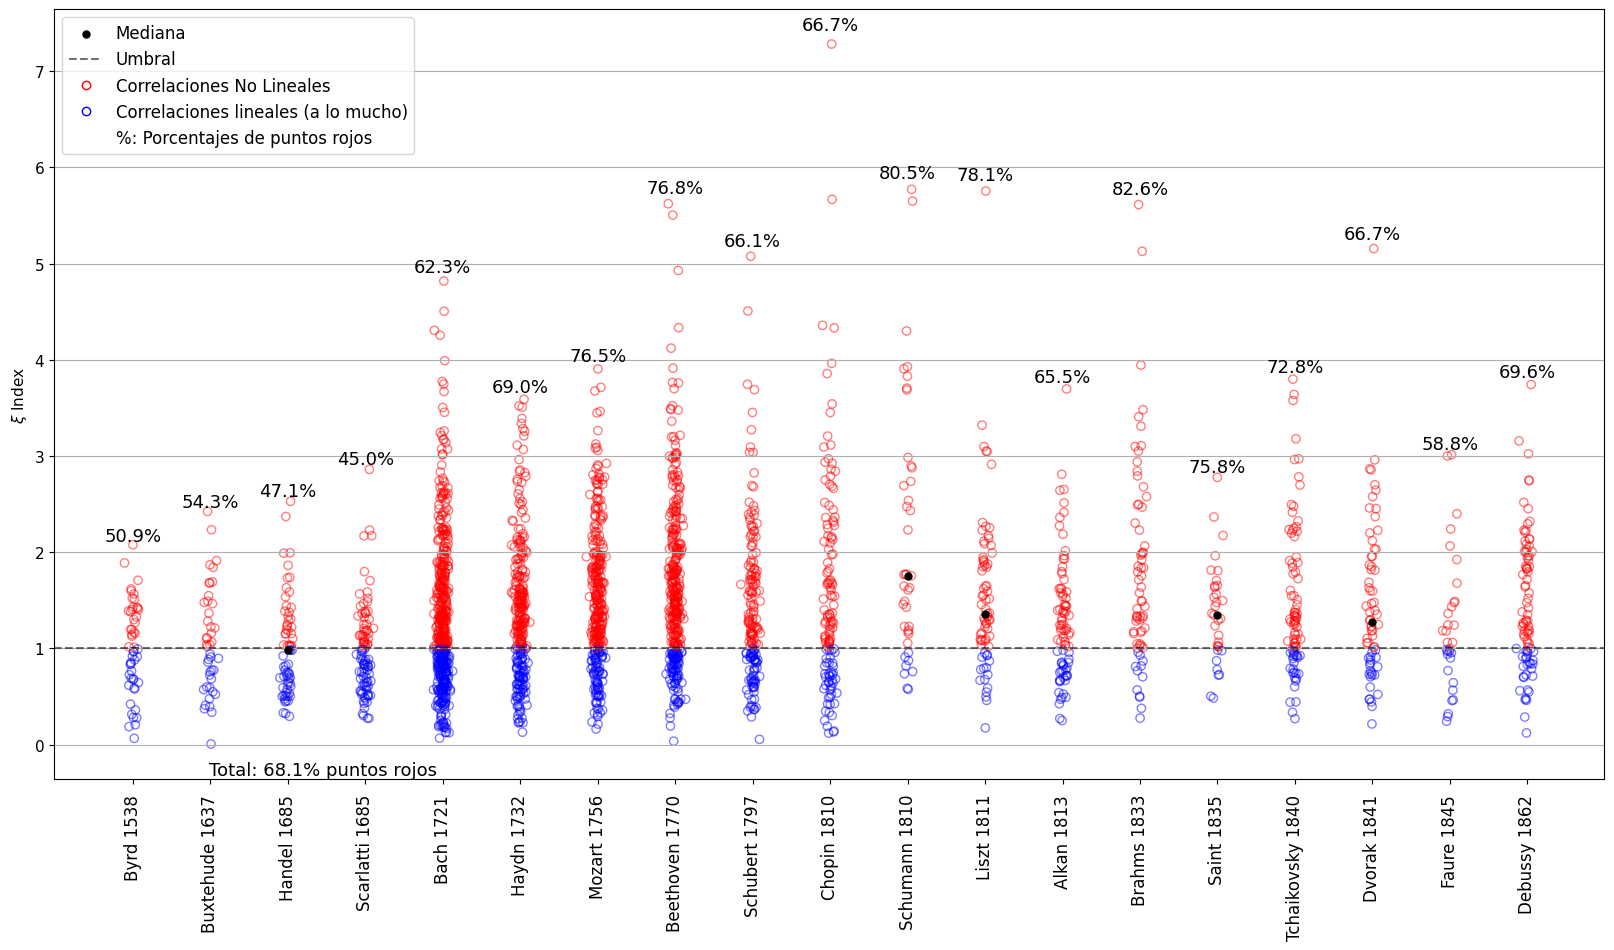

In [7]:
"""Scatter xi"""

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

xi_index = []
carpeta = r'new_data/xi_index_mdfa'
# carpeta = r'data/xi_index1'
for archivo in os.listdir(carpeta):
    ruta_completa = os.path.join(carpeta, archivo)
    array = np.load(ruta_completa)[:,1] -0.2
    xi_index.append(array)


# Aquí, asume que `puntos` es la lista con los num_compositores elementos
median = [np.median(array) for array in xi_index]

fig, ax = plt.subplots(figsize=(20, 10))

total_red_points = 0
total_points = 0
porcentajes = []
for i, d in enumerate(xi_index):
    u = [1.0]*len(d)
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['blue' if d_val < u_val else 'red' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    # Añadir texto con el porcentaje
    ax.text(i + 1,np.max(d[~np.isnan(d)])*1.02, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ymin = ax.get_ylim()[0]   # límite inferior actual del eje y
xmin = ax.get_xlim()[0]   # si quieres fijarlo también en el mínimo de x, por ejemplo

# Añadir texto en coordenadas de datos
ax.text(xmin + 0.1*(ax.get_xlim()[1]-ax.get_xlim()[0]),  # un poquito a la derecha del xmin
        ymin,                                            # justo en ymin
        f'Total: {total_percentage_red:.1f}% puntos rojos',
        ha='left', va='bottom', fontsize=13, color='black')


# ax.set_xlabel(r'Distribución del índice de no linealidad $\xi$ de las melodias', fontsize=13)
ax.set_ylabel(r'$\xi$ Index', fontsize = 11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, 19+1))

# ax.scatter(np.arange(1, 78), puntos1, color='red', s=50, zorder=3, marker = '*', label=r'$U\{\overline{N_J}\}$')
ax.scatter(np.arange(1, 19+1), median, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.axhline(y=1.0, color='black', linestyle='--', alpha =0.55, label = 'Umbral')
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Correlaciones No Lineales')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Correlaciones lineales (a lo mucho)')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
# ax.legend(handles=legend_elements)
ax.legend(loc='upper left', fontsize = 12)
# ax.xaxis.set_label_position('top')  # Movemos la etiqueta del eje x
# ax.xaxis.tick_top()  # Movemos los ticks del eje x a la parte superior
# ax.spines['top'].set_position(('axes', 1.0))  # Movemos la espina superior al tope de la figura
# ax.spines['bottom'].set_position(('axes', -0.1))  # Ocultamos la espina inferior
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(list(datos_composers.keys()))], rotation=90, fontsize = 12)


plt.grid(axis='y')
plt.show()

In [9]:
len(np.concatenate(xi_index))

2677

mean 1.7760969411015746


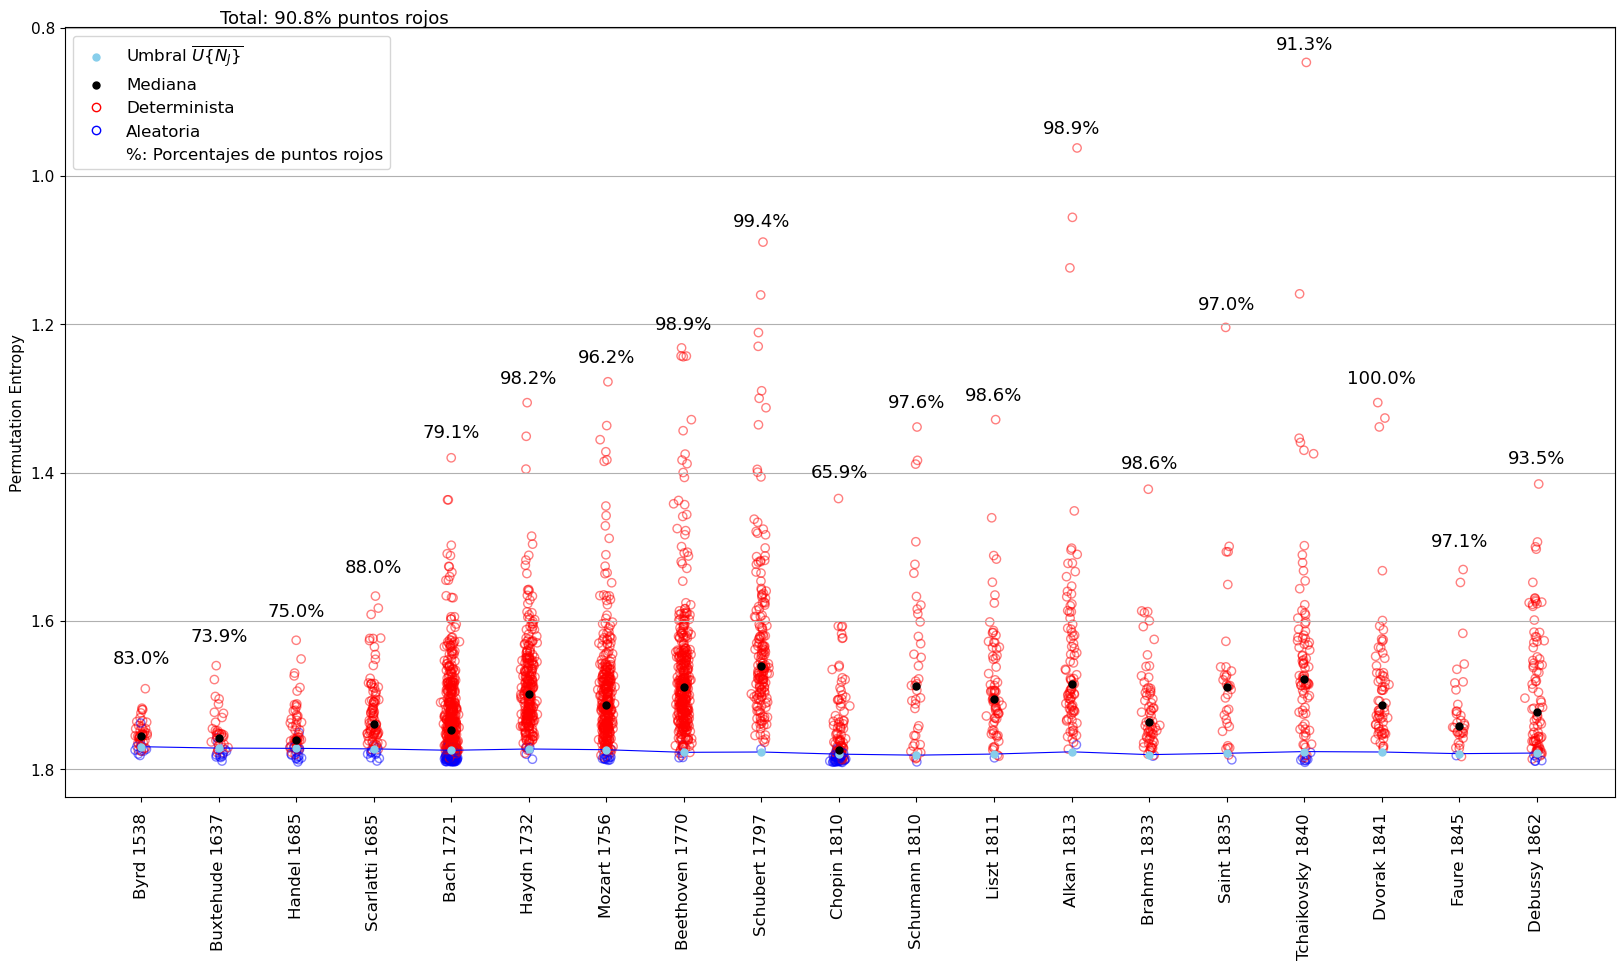

In [8]:
"""Scatter PEs"""

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D

num_compositores = 19
PEs = []
PEs_null = []
carpeta = r'new_data\PEs'
carpeta_null = r'new_data\PEs_null'
for archivo,archivo_null in zip(os.listdir(carpeta), os.listdir(carpeta_null)):
    if "PEs" in archivo:
        ruta_completa = os.path.join(carpeta, archivo)
        ruta_completa_null = os.path.join(carpeta_null, archivo_null)
        array = np.load(ruta_completa)
        array_null = np.load(ruta_completa_null)
        PEs.append(array)
        PEs_null.append(array_null)  
# np.save("PEs_min.npy", np.array(PEs_null, dtype=object))
# Aquí, asume que `puntos` es la lista con los num_compositores elementos
puntos2 = [np.mean(array) for array in PEs_null]
mediana = [np.median(array) for array in PEs]
print('mean',np.mean(puntos2))

fig, ax = plt.subplots(figsize=(20, 10))
# box2 = ax.boxplot(data2, patch_artist=True)

total_red_points = 0
total_points = 0
porcentajes = []
for i, (d, u) in enumerate(zip(PEs, PEs_null)):
    # Añadir dispersión para evitar superposición
    x = np.random.normal(i + 1, 0.04, size=len(d))
    colors = ['red' if d_val < u_val else 'blue' for d_val, u_val in zip(d, [x for x in u])]
    plt.scatter(x, d, alpha=0.5, color='none', edgecolors=colors)
    # Calcular porcentaje de puntos rojos
    num_red = sum(c == 'red' for c in colors)
    total_points += len(d)
    total_red_points += num_red
    percentage_red = (num_red / len(d)) * 100
    porcentajes.append(percentage_red)
    # Calcular la posición del texto sin exceder el margen superior
    
    # Añadir texto con el porcentaje
    ax.text(i + 1,np.min(d)*0.98, f'{percentage_red:.1f}%', ha='center', fontsize=13, color='black')

# np.save('porcentajes_run_avg_50.npy', np.array(porcentajes))
total_percentage_red = (total_red_points / total_points) * 100

# Añadir texto con el porcentaje total
ymin = ax.get_ylim()[0]   # límite inferior actual del eje y
xmin = ax.get_xlim()[0]   # si quieres fijarlo también en el mínimo de x, por ejemplo

# Añadir texto en coordenadas de datos
ax.text(xmin + 0.1*(ax.get_xlim()[1]-ax.get_xlim()[0]),  # un poquito a la derecha del xmin
        ymin,                                            # justo en ymin
        f'Total: {total_percentage_red:.1f}% puntos rojos',
        ha='left', va='bottom', fontsize=13, color='black')

ax.set_ylabel('Permutation Entropy', fontsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_xticks(np.arange(1, num_compositores+1))

ax.scatter(np.arange(1, num_compositores+1), puntos2, color='#87CEEB', s=25, zorder=3, marker = 'o', label=r'Umbral $\overline{U\{ N_J \}}$')
ax.scatter(np.arange(1, num_compositores+1), mediana, color='black',s=25,zorder=3,marker='o',label='Mediana')
ax.plot(np.arange(1, num_compositores+1), puntos2, color='blue', linestyle='-', linewidth=0.8)
# ax.plot(np.arange(1, 18), mediana, color='red', linestyle='-', linewidth=0.8)
ax.plot([],[], marker = 'o',color='none', markeredgecolor='red', label = 'Determinista')
ax.plot([],[], marker='o', color='none', markeredgecolor='blue', label= 'Aleatoria')
ax.plot([],[], marker='none', color='none', label = '%: Porcentajes de puntos rojos')

# Agregar la leyenda al gráfico
ax.legend(loc='upper left',fontsize=12)
plt.gca().invert_yaxis()
ax.set_xticklabels([f"{composer} {datos_composers[composer]['Birth_year']} " for i, composer in enumerate(datos_composers.keys())], rotation=90,fontsize=12)
plt.grid(axis='y')
plt.show()

1538_Byrd_PEs.npy
1637_Buxtehude_PEs.npy
1685_Handel_PEs.npy
1685_Scarlatti_PEs.npy
1721_Bach_PEs.npy
1732_Haydn_PEs.npy
1756_Mozart_PEs.npy
1770_Beethoven_PEs.npy
1797_Schubert_PEs.npy
1810_Chopin_PEs.npy
1810_Schumann_PEs.npy
1811_Liszt_PEs.npy
1813_Alkan_PEs.npy
1833_Brahms_PEs.npy
1835_Saint_PEs.npy
1840_Tchaikovsky_PEs.npy
1841_Dvorak_PEs.npy
1845_Faure_PEs.npy
1862_Debussy_PEs.npy


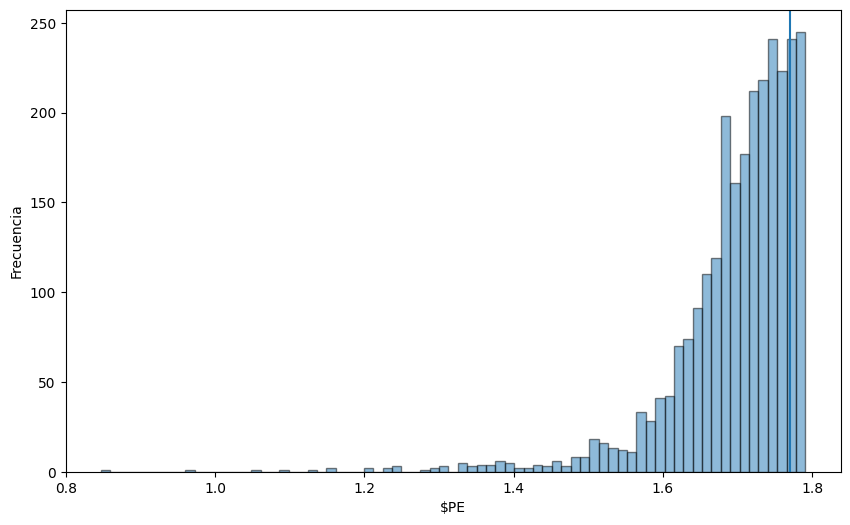

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

# folder_path = 'new_data/xi_index_mdfa'
folder_path = 'new_data/PEs'
arrays = []
plt.figure(figsize=(10, 6))
for filename in os.listdir(folder_path):
    if filename.endswith('.npy'):
        print(filename)
        array = np.load(os.path.join(folder_path, filename))
        arrays.extend(array)
plt.hist(arrays, bins='auto', alpha=0.5, label=filename[5:-7], edgecolor='black')
plt.axvline(x = 1.77)
plt.xlabel(r'$PE')
plt.ylabel('Frecuencia')
# plt.legend()
plt.show()

2677 2677


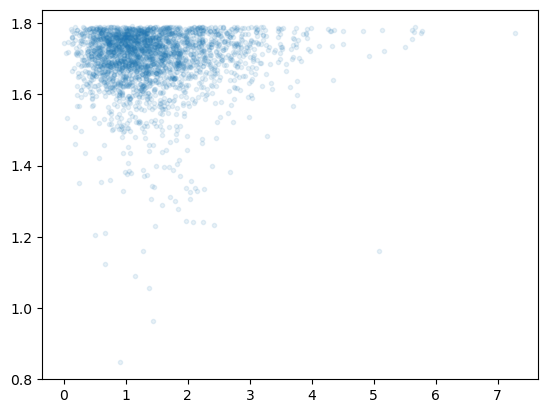

In [12]:
plt.plot(np.concatenate(xi_index), np.concatenate(PEs), '.', alpha=0.1)
print(len(np.concatenate(xi_index)), len(np.concatenate(PEs)  ))

In [10]:
np.load(r'new_data\PEs\1538_Byrd_PEs.npy')

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan])

In [34]:
np.shape(np.load(r'data\xi_index1\1637_Buxtehude_xi.npy'))

(46, 2)

In [35]:
datos_composers['Buxtehude']['# Piezas']

46